BACKGROUND FIT

The goal of this section is to infer background normalization(s) and quantify uncertainties.
We shall also investigate how sensitive is the posterior probability to a difference in priors. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import trapezoid





In [4]:
bins = pd.read_csv('SourceData/s2_binning_info.csv')
resp_nr = pd.read_csv('SourceData/s2_response_nr.csv')
resp_er = pd.read_csv('SourceData/s2_response_er.csv')
bg = pd.read_csv('SourceData/er_and_cevns_background.csv')
events = pd.read_csv('SourceData/events_after_cuts.csv')

In [5]:
s2_bin_centers_log = bins['log_center_pe'].values
s2_bin_centers_lin = bins['linear_center_pe'].values
s2_bin_widths = (bins['end_pe'] - bins['start_pe']).values
s2_bin_edges = np.concatenate([bins['start_pe'].values, [bins['end_pe'].iloc[-1]]])

In [6]:
b_er = bg['er_background_events']
b_cevns = bg['cevns_background_events']
b_nominal = b_er + b_cevns
k_obs, _ = np.histogram(events['s2_area_pe'].values, bins=s2_bin_edges)

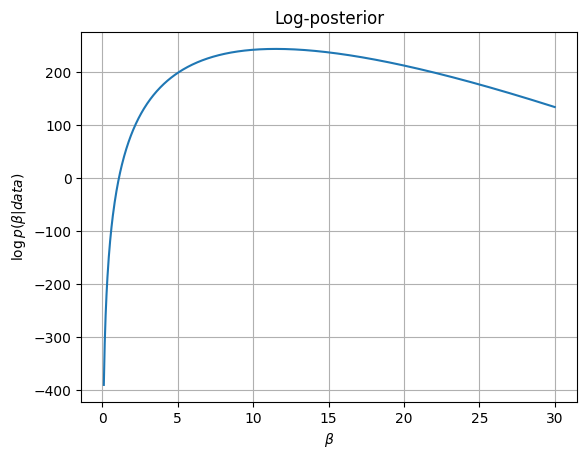

In [7]:
K_tot = np.sum(k_obs)
B_tot = np.sum(b_nominal)

#If we take the prior as being proportional to 1/beta, the log posterior distribution is the following:
def log_posterior(beta):
    return (K_tot - 1)*np.log(beta)-beta*B_tot
#Now let's sample the posterior for values of beta within the range of 0 and 30 and plot
beta_range = np.linspace(0.1,30,1000)
log_posterior_values = log_posterior(beta_range)

plt.figure()
plt.plot(beta_range, log_posterior_values)
plt.xlabel(r'$\beta$')
plt.ylabel(r'$\log p(\beta|data)$')
plt.title('Log-posterior')
plt.grid()
plt.show()



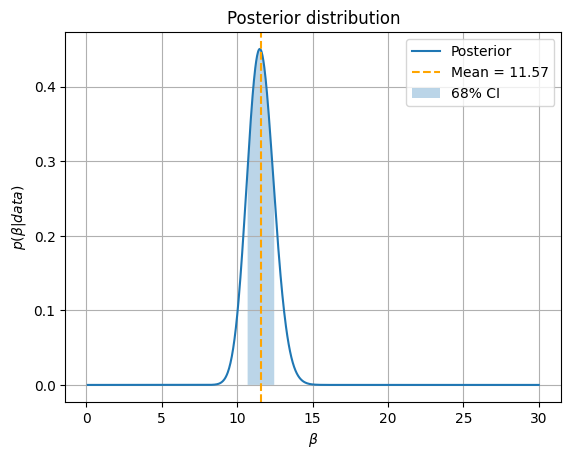

Mean β: 11.5715
68% credible interval: [10.6952, 12.4611]


In [8]:


posterior_unnorm = np.exp(log_posterior_values) #unnormalized posterior

# Normalize
evidence = trapezoid(posterior_unnorm, beta_range) # integrate over parameter space to get evidence
posterior = posterior_unnorm / evidence


plt.figure()
plt.plot(beta_range, posterior, label='Posterior')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$p(\beta|data)$')
plt.title('Posterior distribution')
plt.grid()

# Mean
mean_beta = trapezoid(beta_range * posterior, beta_range)

# CDF
cdf = np.cumsum(posterior) * (beta_range[1] - beta_range[0])

# 68% credible interval--> 0.68 = 0.84-0.16
low = beta_range[np.searchsorted(cdf, 0.16)] #Finds the position with 0.16 accumulated probability density
high = beta_range[np.searchsorted(cdf, 0.84)]#same but for 0.84

plt.axvline(mean_beta, color='orange', linestyle='--', label=f'Mean = {mean_beta:.2f}')
plt.fill_between(beta_range, posterior,
                 where=(beta_range >= low) & (beta_range <= high),
                 alpha=0.3, label='68% CI')
plt.legend()
plt.show()

print(f"Mean β: {mean_beta:.4f}")
print(f"68% credible interval: [{low:.4f}, {high:.4f}]")

Now let's see what happens when instead of a scale invariant prior we use a flat one. 

JAMES CODE GOES HERE

In [21]:
#We first define the Prior \pi(\beta)
beta_min, beta_max = 0.1, 30.0 #0.1 and 30 because same scale already used
prior_val = 1.0 / (beta_max-beta_min)
print(prior_val)




#Calculate the unnormalized posterior
beta_grid=np.linspace(beta_min,beta_max,1000)
unnormalized_posterior = []
for b in beta_grid:
    log_like=-log_likelihood_bg_only(b) 
    unnormalized_posterior.append(np.exp(log_like)*prior_val)
unnormalized_posterior=np.array(unnormalized_posterior)
evidence=trapezoid(unnormalized_posterior,x=beta_grid)
#We now get the normaised posterior distribution
posterior=unnormalized_posterior/evidence


0.033444816053511704


In [22]:
cumulative_posterior = np.cumsum(posterior) * (beta_grid[1] - beta_grid[0])
low_bound = beta_grid[np.searchsorted(cumulative_posterior, 0.16)]
high_bound = beta_grid[np.searchsorted(cumulative_posterior, 0.84)]

print(f"Bayesian Mean β: {mean_beta:.4f}")
print(f"68% Credible Interval: [{low_bound:.4f}, {high_bound:.4f}]")

Bayesian Mean β: 8.0630
68% Credible Interval: [6.1458, 9.9769]


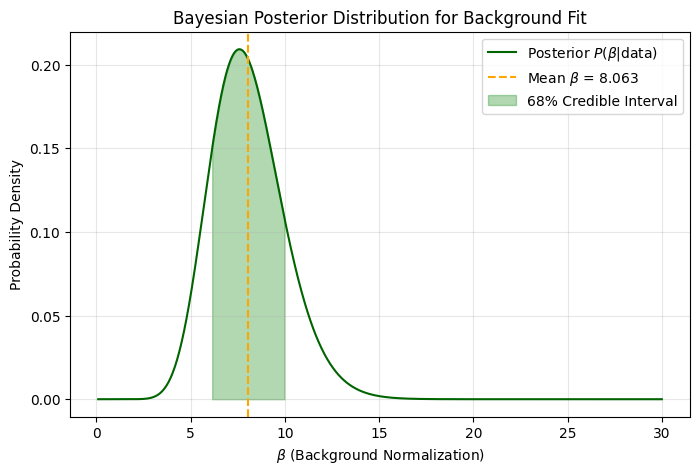

[1.24441895e-24 7.70740592e-23 1.99519873e-21 2.91820083e-20
 2.85265065e-19 2.06649201e-18 1.18746239e-17 5.67428314e-17
 2.33301872e-16 8.46622474e-16 2.76494733e-15 8.25150290e-15
 2.27777499e-14 5.87355077e-14 1.42632943e-13 3.28392446e-13
 7.20907336e-13 1.51623099e-12 3.06787018e-12 5.99286936e-12
 1.13369683e-11 2.08253796e-11 3.72349736e-11 6.49351908e-11
 1.10659150e-10 1.84583489e-10 3.01815761e-10 4.84411960e-10
 7.64074219e-10 1.18570997e-09 1.81206917e-09 2.72971523e-09
 4.05662861e-09 5.95178850e-09 8.62712846e-09 1.23623152e-08
 1.75228553e-08 2.45820929e-08 3.41477206e-08 4.69934852e-08
 6.40968298e-08 8.66832717e-08 1.16278372e-07 1.54768207e-07
 2.04469287e-07 2.68208944e-07 3.49417198e-07 4.52231178e-07
 5.81613181e-07 7.43483460e-07 9.44868819e-07 1.19406812e-06
 1.50083571e-06 1.87658385e-06 2.33460500e-06 2.89031499e-06
 3.56151777e-06 4.36869251e-06 5.33530368e-06 6.48813453e-06
 7.85764439e-06 9.47834996e-06 1.13892306e-05 1.36341574e-05
 1.62623461e-05 1.932883

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(beta_grid, posterior, label='Posterior $P(\\beta | \\text{data})$', color='darkgreen')
plt.axvline(mean_beta, color='orange', linestyle='--', label=f'Mean $\\beta$ = {mean_beta:.3f}')
plt.fill_between(beta_grid, posterior, where=(beta_grid >= low_bound) & (beta_grid <= high_bound), 
                 alpha=0.3, color='green', label='68% Credible Interval')
plt.xlabel('$\\beta$ (Background Normalization)')
plt.ylabel('Probability Density')
plt.title('Bayesian Posterior Distribution for Background Fit')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print(posterior)